# 03 · Demand and offer sensitivity

Build two controlled parameter sweeps and compare every result with an unchanged baseline.

**Time:** about 10 minutes. **Package:** PySPD 0.1.0. **Platform tested:** macOS ARM64, Python 3.13.

Run the cells from top to bottom in a fresh kernel. This notebook contains all
its model-building code and uses only the installed package. All data are
fictional; no GDX file, GAMS runtime, repository checkout, or earlier notebook
is needed. Install `pyspd==0.1.0`, `jupyterlab`, `matplotlib`, and `pandas` in
your environment before opening it. SCIP and HiGHS arrive with PySPD.

In [1]:
import math
import sys
from importlib.metadata import version

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

assert sys.version_info[:2] == (3, 13), "Select a Python 3.13 notebook kernel"
assert version("pyspd") == "0.1.0", "These examples target pyspd==0.1.0"
plt.rcParams.update(
    {
        "figure.figsize": (8, 4),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.2,
        "figure.dpi": 110,
    }
)
pd.options.display.float_format = "{:,.3f}".format
print({name: version(name) for name in ("pyspd", "highspy", "pyscipopt")})

{'pyspd': '0.1.0', 'highspy': '1.15.1', 'pyscipopt': '5.7.1'}


In [2]:
from pyspd.architecture import ModelAssembler
from pyspd.core_energy import (
    CoreEnergyCase,
    CoreEnergyPricingEngine,
    CoreEnergyResultSchema,
    CoreEnergySolvePolicy,
    core_energy_formulation,
)

## Construct a small normalized case

Keys identify `(case, period, offer, block)`. Both offers have a single price
block. One interval lasts one hour. Ramps are nonbinding, and the small
movement tie-break penalty is explicitly set to zero so the arithmetic is
transparent. This is the energy-only LP, solved directly by HiGHS; the reserve
example later demonstrates the full SCIP-to-HiGHS solve policy.

In [3]:
def energy_case(demand=80.0, cheap_capacity=60.0, cheap_price=20.0):
    """One fictional island, two offers, one hour, no losses or ramp limits."""
    period = ("DEMO", "H1")
    region = (*period, "NI")
    offers = frozenset((*period, name) for name in ("CHEAP", "LOCAL"))
    blocks = frozenset((*offer, "1") for offer in offers)
    return CoreEnergyCase(
        case_id="DEMO",
        periods=frozenset({period}),
        regions=frozenset({region}),
        offers=offers,
        offer_blocks=blocks,
        primary_offers=offers,
        offer_region={offer: region for offer in offers},
        required_load={region: demand},
        offer_limit={
            block: cheap_capacity if block[2] == "CHEAP" else 120.0 for block in blocks
        },
        offer_price={
            block: cheap_price if block[2] == "CHEAP" else 70.0 for block in blocks
        },
        generation_start={offer: 0.0 for offer in offers},
        ramp_rate_up={offer: 10000.0 for offer in offers},
        ramp_rate_down={offer: 10000.0 for offer in offers},
        interval_minutes={period: 60.0},
        study_mode={period: 130.0},
        movement_penalty=0.0,
    )

In [4]:
def solve_energy(case):
    built = ModelAssembler().assemble(core_energy_formulation(), case)
    solved = CoreEnergySolvePolicy().solve(built)
    assert solved.solution_loaded, "No optimal solution was loaded"
    results = CoreEnergyResultSchema().collect(built, solved)
    prices = CoreEnergyPricingEngine().price(built, solved)
    generation = {key[2]: value for key, value in results.generation.items()}
    deficit = sum(results.deficit.values())
    surplus = sum(results.surplus.values())
    assert (
        abs(
            sum(generation.values())
            + deficit
            - surplus
            - sum(case.required_load.values())
        )
        < 1e-6
    )
    cost = sum(
        generation[key[2]] * case.offer_price[(*key, "1")] for key in case.offers
    )
    return {
        **generation,
        "demand_mw": sum(case.required_load.values()),
        "cost_nzd_per_hour": cost,
        "price_nzd_per_mwh": next(iter(prices.values.values())),
        "deficit_mw": deficit,
        "surplus_mw": surplus,
    }

## Sweep demand

Each row creates a fresh immutable case. This avoids carrying state between
scenarios. These changes operate on normalized synthetic data; changes to real
GDX symbols should use PySPD's `OverrideInstruction` and `OverrideApplier` API
so the input mutation has an audit record.

In [5]:
baseline = solve_energy(energy_case(demand=80.0))
demands = [20.0, 40.0, 59.0, 61.0, 80.0, 100.0, 140.0]
demand_sweep = pd.DataFrame(solve_energy(energy_case(demand=d)) for d in demands)
demand_sweep["cost_change_from_baseline"] = (
    demand_sweep.cost_nzd_per_hour - baseline["cost_nzd_per_hour"]
)
assert demand_sweep.deficit_mw.max() < 1e-6
assert demand_sweep.cost_nzd_per_hour.is_monotonic_increasing
display(demand_sweep)

,CHEAP,LOCAL,demand_mw,cost_nzd_per_hour,price_nzd_per_mwh,deficit_mw,surplus_mw,cost_change_from_baseline
0,20.000,0.000,20.000,400.000,20.000,0.000,0.000,"-2,200.000"
1,40.000,0.000,40.000,800.000,20.000,0.000,0.000,"-1,800.000"
2,59.000,0.000,59.000,"1,180.000",20.000,0.000,0.000,"-1,420.000"
3,60.000,1.000,61.000,"1,270.000",70.000,0.000,0.000,"-1,330.000"
4,60.000,20.000,80.000,"2,600.000",70.000,0.000,0.000,0.000
5,60.000,40.000,100.000,"4,000.000",70.000,0.000,0.000,"1,400.000"
6,60.000,80.000,140.000,"6,800.000",70.000,0.000,0.000,"4,200.000"


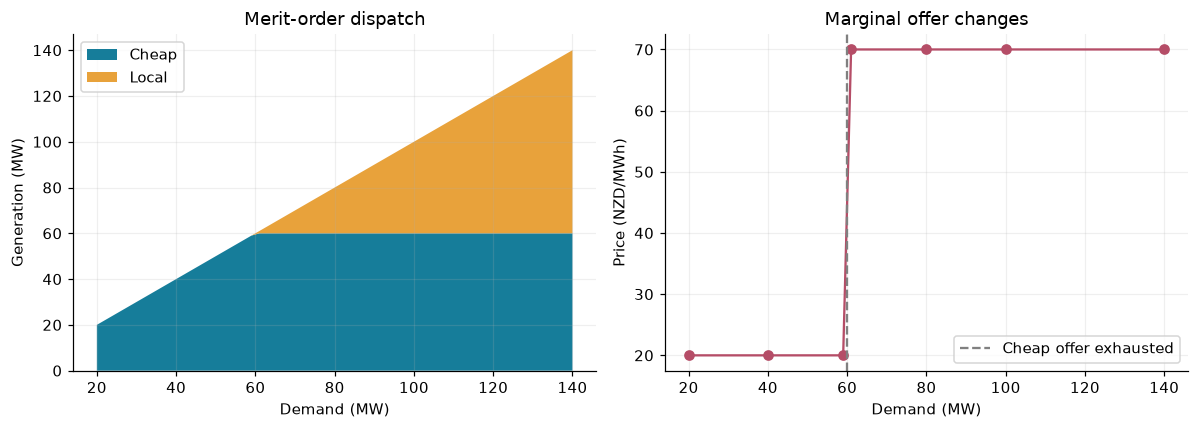

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].stackplot(
    demand_sweep.demand_mw,
    demand_sweep.CHEAP,
    demand_sweep.LOCAL,
    labels=["Cheap", "Local"],
    colors=["#167d9a", "#e8a23b"],
)
axes[0].set(
    xlabel="Demand (MW)", ylabel="Generation (MW)", title="Merit-order dispatch"
)
axes[0].legend()
axes[1].plot(
    demand_sweep.demand_mw, demand_sweep.price_nzd_per_mwh, "o-", color="#b54d67"
)
axes[1].axvline(60, color="grey", linestyle="--", label="Cheap offer exhausted")
axes[1].set(
    xlabel="Demand (MW)", ylabel="Price (NZD/MWh)", title="Marginal offer changes"
)
axes[1].legend()
fig.tight_layout()
display(fig)
plt.close(fig)

## Sweep one offer price at fixed demand

The local offer remains at NZD 70/MWh. When the other offer rises above 70,
its place in the merit order changes. Prices are sampling results joined by
lines for readability; they are not evidence of a smooth price response.

,cheap_offer_price,CHEAP,LOCAL,demand_mw,cost_nzd_per_hour,price_nzd_per_mwh,deficit_mw,surplus_mw
0,10.000,60.000,20.000,80.000,"2,000.000",70.000,0.000,0.000
1,30.000,60.000,20.000,80.000,"3,200.000",70.000,0.000,0.000
2,60.000,60.000,20.000,80.000,"5,000.000",70.000,0.000,0.000
3,80.000,0.000,80.000,80.000,"5,600.000",70.000,0.000,0.000
4,100.000,0.000,80.000,80.000,"5,600.000",70.000,0.000,0.000


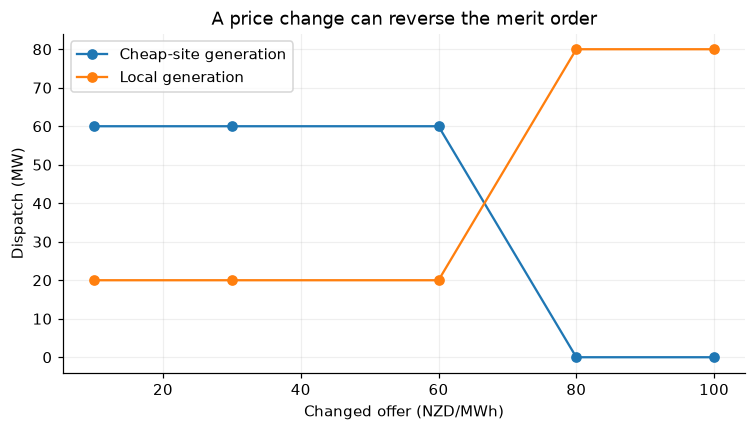

In [7]:
offer_sweep = pd.DataFrame(
    {"cheap_offer_price": price, **solve_energy(energy_case(cheap_price=price))}
    for price in [10.0, 30.0, 60.0, 80.0, 100.0]
)
display(offer_sweep)
assert math.isclose(offer_sweep.iloc[-1].CHEAP, 0.0, abs_tol=1e-6)
assert solve_energy(energy_case()) == baseline, "The baseline should not have changed"
fig, ax = plt.subplots()
ax.plot(
    offer_sweep.cheap_offer_price,
    offer_sweep.CHEAP,
    "o-",
    label="Cheap-site generation",
)
ax.plot(
    offer_sweep.cheap_offer_price, offer_sweep.LOCAL, "o-", label="Local generation"
)
ax.set(
    xlabel="Changed offer (NZD/MWh)",
    ylabel="Dispatch (MW)",
    title="A price change can reverse the merit order",
)
ax.legend()
display(fig)
plt.close(fig)

## Try it

Sweep cheap-offer capacity instead of price. Compare total cost, dispatch, and
price separately: an unchanged marginal price does not imply an unchanged
total cost. These are illustrative sensitivities, not forecasts.